# Classical Shadows on a Two-Qubit Ising (ZZ) Time Evolution

This notebook is a companion example for the Qurrium paper's classical-shadow
demonstrations. It processes real hardware data (device labeled "ASQ" in the
paper) alongside a noiseless simulation ("ideal") for a 2-qubit system evolving
under a pure $J\,Z\otimes Z$ Ising interaction, digitized into 25 time steps
(`time_step` = time step index) using a circuit that exactly simulates
$e^{-iJZZt}$ — no Trotter approximation. We call this `circuit_ZZ`, stored
on disk under its original name, `circuit_two_cx`. The measurement data is
saved in Qurrium's data format and provided in a separate subdirectory. At
each time step we:

1. Load 90 classical-shadow snapshots (measurement counts + randomly chosen
   single-qubit bases) per qubit, for both the real device and the ideal
   simulator.
2. Estimate purities, two-qubit Pauli expectation values, and state overlaps
   from the shadows using `qurry.process.classical_shadow`.
3. Compare hardware results against the ideal simulation and an analytic
   prediction.

Depolarizing-noise error mitigation on these purities is covered separately,
in `ex3-depolarizing-mitigation.ipynb`.

## Setup

Imports `qurry`'s classical-shadow processing functions directly (rather than
the `ShadowUnveil` experiment manager used in `ex1-cluster-state.ipynb`),
since here we're post-processing externally-saved counts/basis data rather
than running circuits ourselves.

In [13]:
from qurry import __version__, EntropyMeasure
print("| Using qurrium version:", __version__)

| Using qurrium version: 1.0.0.dev3


In [14]:
import matplotlib.pyplot as plt
pltparams = {'legend.fontsize': 18,
             'legend.handlelength': 1,
             'xtick.labelsize':18,'ytick.labelsize':18,
             'axes.labelsize':18,
             "text.usetex": True}
plt.rcParams.update(pltparams)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']
plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

In [15]:
import json
import numpy as np
from qurry.process.classical_shadow import classical_shadow_complex # >0.14.0 return three dictionay, 0.13 return a single typedict
from projector_rho import custom_mean_rho, MY_METHOD_KEY

`expectation_from_rho(mean_of_rho, operators)` is a small helper used later for a cross-check: given a shadow-estimated density matrix (`mean_of_rho`, the first element of `classical_shadow_complex`'s return tuple), it computes $\mathrm{Tr}(\rho O)$ directly for a list of operators — an alternative route to the same expectation values that `given_operators=` computes inside `classical_shadow_complex` itself.

In [16]:
def expectation_from_rho(mean_of_rho, operators):
    """Compute Tr(rho @ O) for each operator O using mean_of_rho from ClassicalShadowBasic.

    Args:
        mean_of_rho: basic['mean_of_rho'] where basic = classical_shadow_complex(...)[0]
        operators:   list of numpy arrays, each (2^k x 2^k)

    Returns:
        list of complex128 expectation values
    """
    rho = np.array(mean_of_rho, dtype='complex128')
    return [np.trace(rho @ np.array(op, dtype='complex128')) for op in operators]

## Purity and observable expectation values across the time evolution

For each of the 25 time steps (`time_step`), load the corresponding JSON file: 90 classical-shadow snapshots (measurement counts and their associated random single-qubit bases) for both the real-device run (`results`, labeled **QPU** in the plots below) and the noiseless-simulator run (`ideal_results`). For each, `classical_shadow_complex(...)` (returning `(basic, purity, estimation)`) is called on qubit 0 alone, qubit 1 alone, and both qubits jointly — the joint call also passes `given_operators=given_ops`, the six two-qubit Pauli operators $I_0X_1, X_0I_1, X_0X_1, I_0Y_1, Y_0I_1, Y_0Y_1$, to get shadow-estimated expectation values directly.

In [ ]:
# Refactored by Claude (claude-sonnet-4-6) on 2026-04-13
# Reduced redundancy: define given_ops once and wrap csc calls in a helper function

given_ops = [np.kron(X,I2), np.kron(I2,X), np.kron(X,X),
             np.kron(Y,I2), np.kron(I2,Y), np.kron(Y,Y)]

def run_csc(counts, u_array):
    csc0   = classical_shadow_complex(shots=32, counts=counts, random_basis_array=u_array, selected_classical_registers=[0])
    csc1   = classical_shadow_complex(shots=32, counts=counts, random_basis_array=u_array, selected_classical_registers=[1])
    cscall = classical_shadow_complex(shots=32, counts=counts, random_basis_array=u_array, selected_classical_registers=[0,1], given_operators=given_ops)
    return csc0[1]["purity"], csc1[1]["purity"], cscall[1]["purity"], cscall[2]["estimate_of_given_operators"]

q0angle, q1angle, qsangle, exps = [], [], [], []
ideal_q0angle, ideal_q1angle, ideal_qsangle, ideal_exps = [], [], [], []

for time_step in range(25):
    fn = dirn + "results.angle_{}_of_24.qubits_1_2.circuit_two_cx.json".format(time_step)
    with open(fn, "r") as file:
        data = json.load(file)

    expcount   = [data["results"][i][0] for i in range(90)]
    expu       = [data["results"][i][1] for i in range(90)]
    idealcount = [{k: round(v * 32) for k, v in data["ideal_results"][i][0].items()} for i in range(90)]
    idealu     = [data["ideal_results"][i][1] for i in range(90)]

    q0a,  q1a,  qsa,  exp_val  = run_csc(expcount,   expu)
    iq0a, iq1a, iqsa, iexp_val = run_csc(idealcount, idealu)

    q0angle.append(q0a);         q1angle.append(q1a);         qsangle.append(qsa);         exps.append(exp_val)
    ideal_q0angle.append(iq0a);  ideal_q1angle.append(iq1a);  ideal_qsangle.append(iqsa);  ideal_exps.append(iexp_val)

exps       = np.array(exps)
ideal_exps = np.array(ideal_exps)


### Figure: single- and two-qubit purity vs. time

Panel (a): single-qubit purities $\hat p_2$ for $q_0$ and $q_1$ against the analytic prediction — under $ZZ$ Ising evolution starting from a product state, each qubit's reduced state becomes mixed as entanglement builds up, so purity dips below 1. Panel (b): the 2-qubit purity $q_0 q_1$, which noiseless unitary evolution keeps at 1 exactly (the *ideal* markers should sit at 1 throughout); the QPU trace's deviation from 1 reflects hardware noise — see `ex3-depolarizing-mitigation.ipynb` for a depolarizing-noise-mitigated version of these purities.

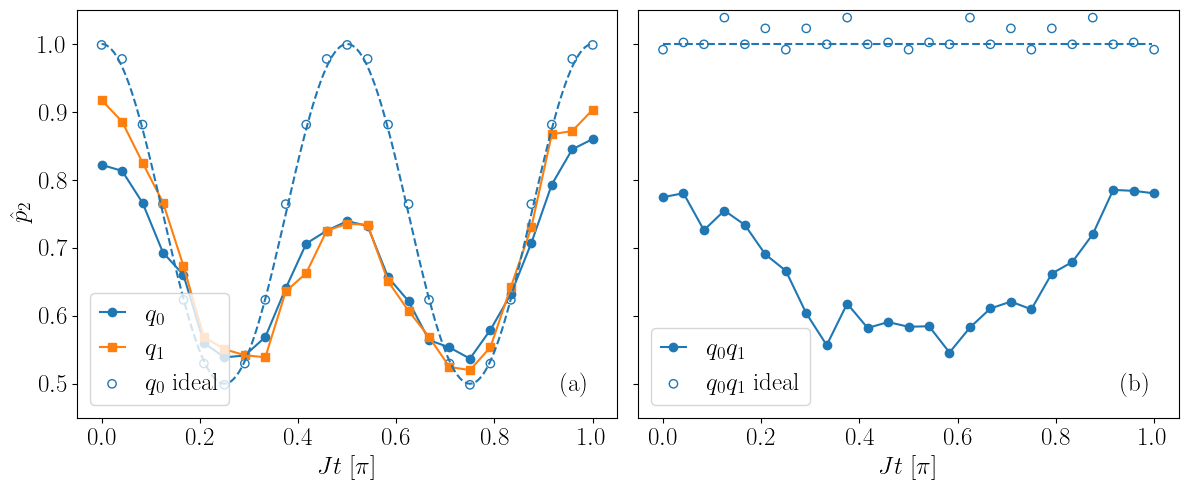

In [38]:
ts = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200
yticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: purity of q_0
ax1.plot(ts, q0angle,          label=r'$q_0$',           linestyle='-',  marker='o')
ax1.plot(ts, q1angle,          label=r'$q_1$',           linestyle='-',  marker='s')
ax1.plot(manyt, 1-2*np.sin(manyt*np.pi)**2*np.cos(manyt*np.pi)**2, linestyle='--', color='C0')
ax1.scatter(ts, ideal_q0angle, label=r'$q_0$ ideal',     facecolors='none', edgecolors='C0', marker='o')
#ax1.plot(ts, mitigated_q0angle, label=r'$q_0$ mitigated', color='C2', linestyle='-.', marker='^')
#ax1.plot(ts, mitigated_q1angle, label=r'$q_1$ mitigated', color='C1', linestyle='-.', marker='v')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$\hat{p}_2$')
ax1.set_ylim(0.45, 1.05)
ax1.set_yticks(yticks)
ax1.legend(loc='lower left')
ax1.text(0.95, 0.05, '(a)', transform=ax1.transAxes, ha='right', va='bottom', fontsize=18)

# Right: purity of q_0 q_1
ax2.plot(ts, qsangle,          label=r'$q_0 q_1$',       linestyle='-', marker='o')
ax2.scatter(ts, ideal_qsangle, label=r'$q_0 q_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.plot(manyt,np.ones(manyt.shape), linestyle='--', color='C0')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.set_ylim(0.45, 1.05)
ax2.set_yticks(yticks)
ax2.legend(loc='lower left')
ax2.text(0.95, 0.05, '(b)', transform=ax2.transAxes, ha='right', va='bottom', fontsize=18)

fig.tight_layout()
plt.show()


### Figure: 2nd-order Rényi entropy vs. time

Same purities as above, converted to entropy via $S^{(2)} = -\log_2(\hat{p}_2)$: panel (a) single-qubit entanglement entropy growth for $q_0$, $q_1$; panel (b) the full system's entropy, which should stay at 0 for a noiseless pure-state evolution — so the QPU curve here is a direct entropy-based readout of hardware noise.

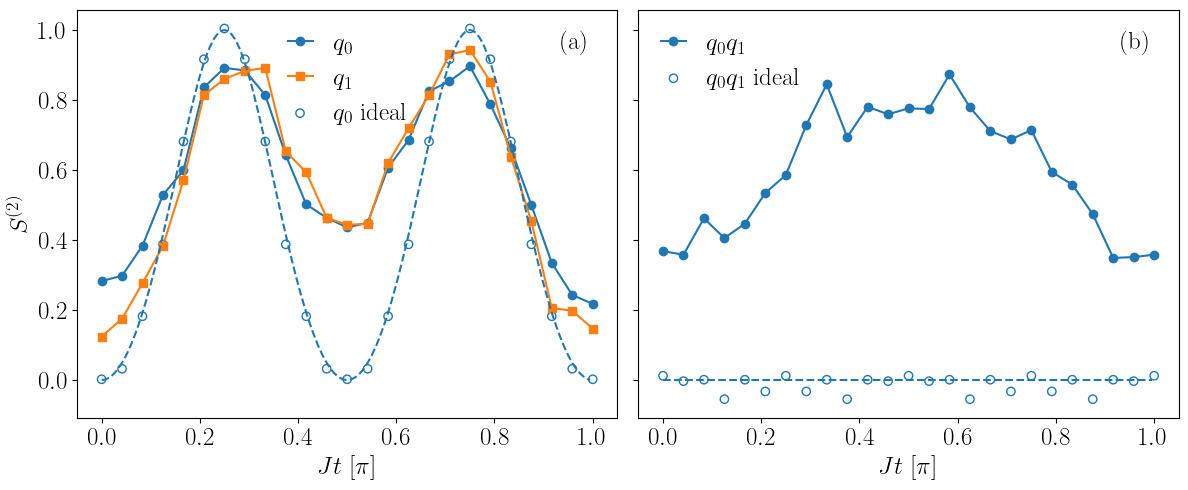

In [35]:
ts    = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: S_2 of q_0, q_1
ax1.plot(ts, -np.log2(q0angle),          label=r'$q_0$',       linestyle='-',  marker='o')
ax1.plot(ts, -np.log2(q1angle),          label=r'$q_1$',       linestyle='-',  marker='s')
ax1.plot(manyt, -np.log2(1 - 2*np.sin(manyt*np.pi)**2*np.cos(manyt*np.pi)**2), linestyle='--', color='C0')
ax1.scatter(ts, -np.log2(ideal_q0angle), label=r'$q_0$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$S^{(2)}$')
ax1.legend(loc='best',frameon=False)
ax1.text(0.95, 0.95, '(a)', transform=ax1.transAxes, ha='right', va='top', fontsize=18)

# Right: S_2 of q_0 q_1
ax2.plot(ts, -np.log2(qsangle),          label=r'$q_0 q_1$',       linestyle='-', marker='o')
ax2.scatter(ts, -np.log2(ideal_qsangle), label=r'$q_0 q_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.plot(manyt, np.zeros(manyt.shape),   linestyle='--', color='C0')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.legend(loc='upper left',frameon=False)
ax2.text(0.95, 0.95, '(b)', transform=ax2.transAxes, ha='right', va='top', fontsize=18)

fig.tight_layout()
plt.show()


### Cross-check: expectation values from the reconstructed density matrix

As a sanity check (mirroring the manual-trace check in `ex1-cluster-state.ipynb`), this recomputes the same six two-qubit Pauli expectation values a second way: instead of `given_operators=`, it reconstructs the full shadow-estimated density matrix `mean_of_rho` (via `rho_method='single_shots_vectorized'`) and takes $\mathrm{Tr}(\rho  O)$ directly with `expectation_from_rho`, for both QPU and ideal data at every time step.

In [36]:
# Computes expectation values of two-qubit Pauli operators (XI, IX, XX, YI, IY, YY)
# from the classical shadow estimated state rho(t), for both experimental and ideal data.
given_ops = [np.kron(X,I2), np.kron(I2,X), np.kron(X,X),
             np.kron(Y,I2), np.kron(I2,Y), np.kron(Y,Y)]
exps_rho = []
ideal_exps_rho = []

for time_step in range(25):
    fn = dirn + 'results.angle_{}_of_24.qubits_1_2.circuit_two_cx.json'.format(time_step)
    with open(fn, 'r') as file:
        data = json.load(file)

    expcount   = [data['results'][i][0] for i in range(90)]
    expu       = [data['results'][i][1] for i in range(90)]
    idealcount = [{k: round(v * 32) for k, v in data['ideal_results'][i][0].items()} for i in range(90)]
    idealu     = [data['ideal_results'][i][1] for i in range(90)]

    basic,       _, _ = classical_shadow_complex(shots=32, counts=expcount,   random_basis_array=expu,   selected_classical_registers=[0,1], rho_method='single_shots_vectorized')
    ideal_basic, _, _ = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[0,1], rho_method='single_shots_vectorized')

    exps_rho.append(expectation_from_rho(basic['mean_of_rho'], given_ops))
    ideal_exps_rho.append(expectation_from_rho(ideal_basic['mean_of_rho'], given_ops))

exps_rho       = np.array(exps_rho).real
ideal_exps_rho = np.array(ideal_exps_rho).real

### Figure: two-qubit Pauli correlations vs. time

Shadow-estimated expectation values (via the `expectation_from_rho` cross-check route) of the $X$-type operators $I_0X_1$, $X_0X_1$ (panel a) and $Y$-type operators $I_0Y_1$, $Y_0Y_1$ (panel b), for QPU vs. ideal data, overlaid with their analytic predictions under the pure $J\,Z\otimes Z$ evolution. 

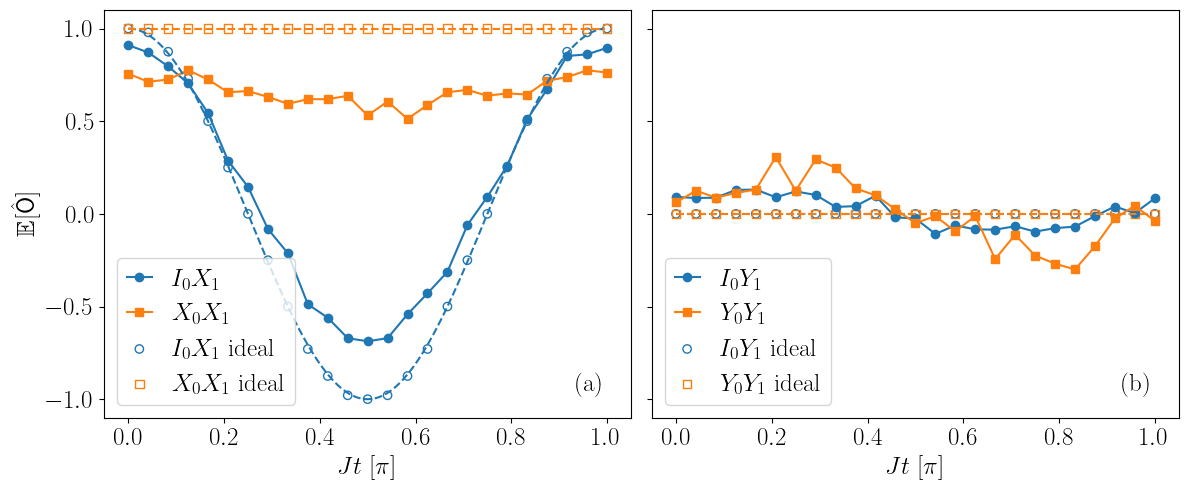

In [37]:
ts = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: X components
ax1.plot(ts, exps_rho[:,0],      label=r'$I_0X_1$', linestyle='-', marker='o')
ax1.plot(ts, exps_rho[:,2],      label=r'$X_0X_1$', linestyle='-', marker='s')
ax1.plot(manyt, np.cos(manyt*np.pi*2), linestyle='--', color='C0')
ax1.plot(manyt,np.ones(manyt.shape), linestyle='--', color='C1')
ax1.scatter(ts, ideal_exps_rho[:,0], label=r'$I_0X_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax1.scatter(ts, ideal_exps_rho[:,2], label=r'$X_0X_1$ ideal', facecolors='none', edgecolors='C1', marker='s')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$\mathbb{E}[\hat{\mathsf{O}}]$')
ax1.legend(loc='lower left')
ax1.text(0.95, 0.05, '(a)', transform=ax1.transAxes, ha='right', va='bottom', fontsize=18)

# Right: Y components
ax2.plot(ts, exps_rho[:,3],      label=r'$I_0Y_1$', linestyle='-', marker='o')
ax2.plot(ts, exps_rho[:,5],      label=r'$Y_0Y_1$', linestyle='-', marker='s')
ax2.plot(manyt,np.zeros(manyt.shape), linestyle='--', color='C0')
ax2.plot(manyt,np.zeros(manyt.shape), linestyle='--', color='C1')
ax2.scatter(ts, ideal_exps_rho[:,3], label=r'$I_0Y_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.scatter(ts, ideal_exps_rho[:,5], label=r'$Y_0Y_1$ ideal', facecolors='none', edgecolors='C1', marker='s')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.legend(loc='lower left')
ax2.text(0.95, 0.05, '(b)', transform=ax2.transAxes, ha='right', va='bottom', fontsize=18)

fig.tight_layout()
plt.show()


### State overlap with the initial state

Two independent ways to estimate the overlap between the all-plus initial state $\rho_0 = |{+}{+}\rangle\langle{+}{+}|$ and the shadow-estimated state $\rho(t)$ at each time step:

- **Linear overlap** `linoverlap` $= \mathrm{Tr}(\rho_0\,\rho(t))$, computed directly from the averaged shadow `mean_of_rho` (`rho_method='multi_shots'`) — valid here because $\rho_0$ is a *known, fixed* product state, exactly as in ex1's linear-overlap section.
- **Nonlinear overlap** `overlap`, using the `projector_rho.custom_mean_rho` estimator from ex1's nonlinear-overlap section — but here the "reference" state's per-snapshot projector (`proj_c_list`) is taken from this same experiment's own $t{=}0$ data (`time_step == 0`) rather than from an analytic density matrix, and is then reused as the fixed reference for every later time step. This demonstrates the general-purpose nonlinear estimator on real data, without assuming the initial state is known analytically.

In [ ]:
# Computes the linear overlap Tr(rho0 @ rho(t)) between the initial state rho0
# and the shadow-estimated state rho(t) at each time step, for both experimental and ideal data.
psi = np.ones(2**2, dtype='complex128') / np.sqrt(2**2)
rho0 = np.outer(psi, psi.conj())
linoverlap = []
ideal_linoverlap = []
overlap = []
ideal_overlap = []
rho_c_list = None
ideal_rho_c_list = None

for time_step in range(25):
    fn = dirn + 'results.angle_{}_of_24.qubits_1_2.circuit_two_cx.json'.format(time_step)
    with open(fn, 'r') as file:
        data = json.load(file)

    expcount   = [data['results'][i][0] for i in range(90)]
    expu       = [data['results'][i][1] for i in range(90)]
    idealcount = [{k: round(v * 32) for k, v in data['ideal_results'][i][0].items()} for i in range(90)]
    idealu     = [data['ideal_results'][i][1] for i in range(90)]

    basic,       _, _ = classical_shadow_complex(shots=32, counts=expcount,   random_basis_array=expu,   selected_classical_registers=[0,1], rho_method='multi_shots')
    ideal_basic, _, _ = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[0,1], rho_method='multi_shots')

    linoverlap.append(np.trace(rho0 @ np.array(basic['mean_of_rho'], dtype='complex128')))
    ideal_linoverlap.append(np.trace(rho0 @ np.array(ideal_basic['mean_of_rho'], dtype='complex128')))

    proj_t = custom_mean_rho(
        shots=32, counts=expcount, random_basis_array=expu,
        selected_classical_registers=[0, 1], rho_method=MY_METHOD_KEY,
    )
    ideal_proj_t = custom_mean_rho(
        shots=32, counts=idealcount, random_basis_array=idealu,
        selected_classical_registers=[0, 1], rho_method=MY_METHOD_KEY,
    )

    if time_step == 0:
        proj_c_list       = np.array(proj_t['average_snapshots_rho_list'],       dtype='complex128')
        ideal_proj_c_list = np.array(ideal_proj_t['average_snapshots_rho_list'], dtype='complex128')

    rho_m_list       = np.array(basic['average_snapshots_rho_list'],       dtype='complex128')
    ideal_rho_m_list = np.array(ideal_basic['average_snapshots_rho_list'], dtype='complex128')
    Nu = len(rho_m_list)

    trclusterrho       = np.einsum('nij,nji->n', proj_c_list,       rho_m_list)
    ideal_trclusterrho = np.einsum('nij,nji->n', ideal_proj_c_list, ideal_rho_m_list)
    overlap.append(trclusterrho.sum() / Nu)
    ideal_overlap.append(ideal_trclusterrho.sum() / Nu)

linoverlap       = np.array(linoverlap).real
ideal_linoverlap = np.array(ideal_linoverlap).real
overlap          = np.array(overlap).real
ideal_overlap    = np.array(ideal_overlap).real

### Figure: state overlap vs. time

Two-panel comparison of the overlap estimates above against the pure-$ZZ$-Ising analytic prediction $\cos^2(J t)$ (dashed): panel (a) the linear overlap `linoverlap`/`ideal_linoverlap`, panel (b) the cross-shadow overlap `overlap`/`ideal_overlap`, both for QPU (solid, real hardware) and ideal (open markers, noiseless simulation). 

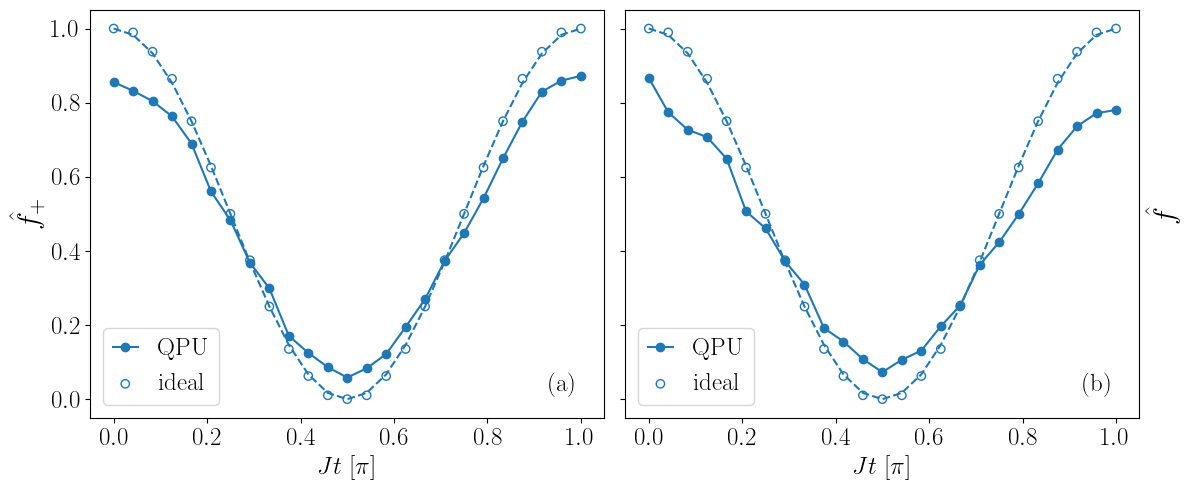

In [28]:
ts = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: linear overlap Tr(rho0 @ rho(t))
ax1.plot(ts, linoverlap,          label=r'QPU',   linestyle='-', marker='o')
ax1.plot(ts, np.cos(ts*np.pi)**2, linestyle='--', color='C0')
ax1.scatter(ts, ideal_linoverlap, label=r'ideal', facecolors='none', edgecolors='C0', marker='o')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$\hat{f}_{+}$', fontsize=22)
ax1.legend(loc='lower left')
ax1.text(0.95, 0.05, '(a)', transform=ax1.transAxes, ha='right', va='bottom', fontsize=18)

# Right: overlap
ax2.plot(ts, overlap,          label=r'QPU',   linestyle='-', marker='o')
ax2.scatter(ts, ideal_overlap, label=r'ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.plot(ts, np.cos(ts*np.pi)**2, linestyle='--', color='C0')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.set_ylabel(r'$\hat{f}$', fontsize=22)
ax2.yaxis.set_label_position('right')
ax2.legend(loc='lower left')
ax2.text(0.95, 0.05, '(b)', transform=ax2.transAxes, ha='right', va='bottom', fontsize=18)

fig.tight_layout()
plt.show()
